<a href="https://colab.research.google.com/github/sanjananagendra16-cpu/Machine-Learning/blob/main/restaurant_review_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.8
Confusion Matrix:
 [[79 18]
 [22 81]]


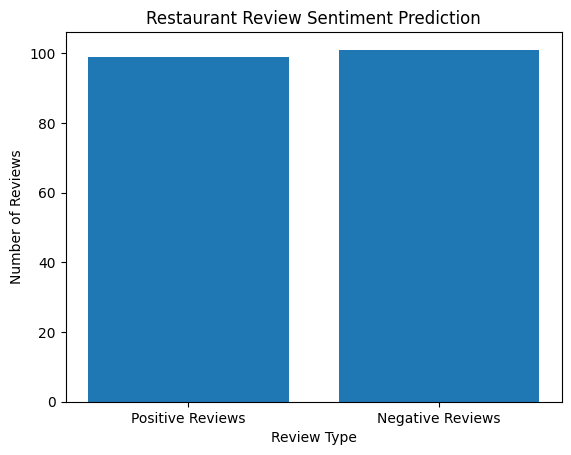

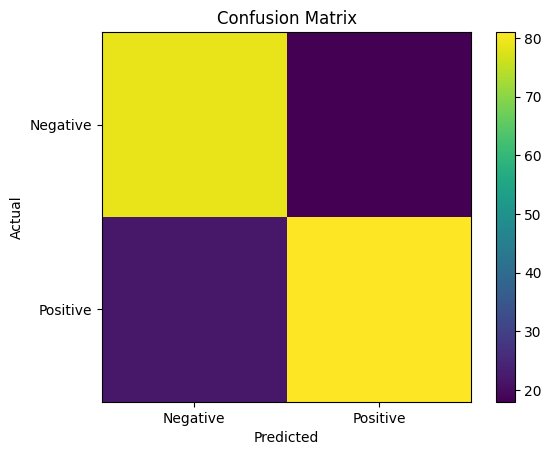

Positive Review ⭐


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
dataset = pd.read_csv("/content/Restaurant_Reviews.tsv", delimiter='\t')

# Features and labels
X = dataset['Review']
y = dataset['Liked']

# Convert text to numbers
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(X).toarray()

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# -------------------------
# Chart 1: Prediction Bar Chart
# -------------------------
positive = sum(y_pred)
negative = len(y_pred) - positive

labels = ['Positive Reviews', 'Negative Reviews']
values = [positive, negative]

plt.figure()
plt.bar(labels, values)
plt.title("Restaurant Review Sentiment Prediction")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")
plt.show()

# Chart 2: Confusion Matrix Visualization
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

ticks = np.arange(2)
plt.xticks(ticks, ['Negative', 'Positive'])
plt.yticks(ticks, ['Negative', 'Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Test review
review = ["The food was very tasty and service was great"]
review = cv.transform(review).toarray()

prediction = model.predict(review)

if prediction == 1:
    print("Positive Review ⭐")
else:
    print("Negative Review ⭐")